In [1]:
import pandas as pd
import plotly.express as px
import ast

In [2]:
df = pd.read_csv(
    "../simulation_conditions_data/neighbors/NeighborsMap-100by100-Agents1000-Neighbors20-2025-10-02-225806Z.csv",
    converters={'neighbors': ast.literal_eval}
)
df.head(5)

,x,y,neighbors
0,63.55,64.64,"[24, 449, 611, 159, 137, 58, 220, 243, 205, 50..."
1,16.25,61.37,"[973, 982, 15, 46, 462, 689, 197, 718, 41, 834..."
2,95.67,86.03,"[351, 932, 80, 274, 970, 980, 974, 25, 348, 28..."
3,82.70,78.21,"[661, 734, 495, 482, 819, 534, 156, 143, 338, ..."
4,12.99,39.01,"[765, 975, 199, 691, 40, 804, 303, 533, 452, 4..."


In [4]:
center = 40 # arbitrary agent
df['category'] = 'other'
for n in df.loc[center, 'neighbors']:
    df.loc[n, 'category'] = 'neighbor'
df.loc[center, 'category'] = 'center'

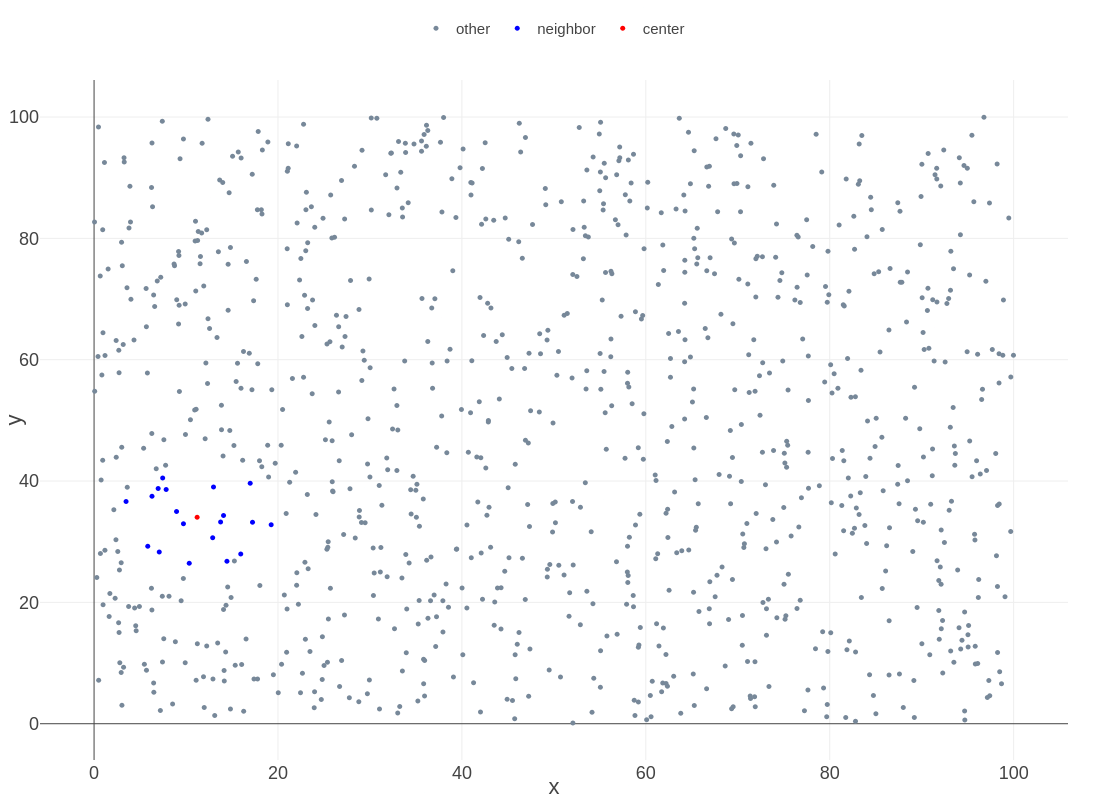

In [8]:
fig = px.scatter(df,
                 x="x", 
                 y="y", 
                 color="category",
                 color_discrete_map={"other": "lightslategrey", "center": "red", "neighbor": "blue"})
fig.update_traces(marker=dict(size=5))
fig.update_layout(
    legend=dict(title_text='', 
                font_size=15,
                orientation="h",
                xanchor="center",
                x=0.5,
                yanchor="top",
                y=1.1),
    margin=dict(l=40, r=40, t=40, b=40),
    width=900, 
    height=800,
    template='presentation')
fig.show()